<a href="https://colab.research.google.com/github/Limeng-svg/Grounded-PPE-Safety-Copilot/blob/main/notebooks/04_class_threshold_calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip -q install \
    "ultralytics==8.4.129" \
    "git+https://github.com/ultralytics/CLIP.git@68dce32140994dfcb645a1320c4ebdc034fc19fd"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive, files
from pathlib import Path
from collections import Counter
from datetime import datetime, timezone

import json
import shutil
import tempfile
import yaml
import torch
import ultralytics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

assert ultralytics.__version__ == "8.4.129", (
    "Restart the Colab runtime and run the notebook again."
)

assert torch.cuda.is_available(), (
    "Select a GPU runtime in Colab."
)

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Grounded-PPE-Safety-Copilot"
)

SOURCE = PROJECT_ROOT / "data/mini_eval"

CLASS_NAMES = [
    "person",
    "hard_hat",
    "safety_vest",
]

C1_PROMPTS = [
    "person",
    "safety helmet",
    "reflective safety vest",
]

EXPECTED_COUNTS = Counter({
    0: 60,
    1: 53,
    2: 37,
})

images = sorted(
    (SOURCE / "images").glob("*.jpg")
)

assert len(images) == 12, (
    f"Expected 12 images, found {len(images)}."
)

LOCAL_DATA = Path(
    tempfile.mkdtemp(
        prefix="ppe_threshold_calibration_",
        dir="/content",
    )
)

(LOCAL_DATA / "images/val").mkdir(
    parents=True
)

(LOCAL_DATA / "labels/val").mkdir(
    parents=True
)

counts = Counter()

for image_path in images:
    label_path = (
        SOURCE
        / "labels"
        / f"{image_path.stem}.txt"
    )

    assert label_path.is_file(), (
        f"Missing label: {label_path}"
    )

    for line in label_path.read_text(
        encoding="utf-8"
    ).splitlines():
        if line.strip():
            parts = line.split()
            assert len(parts) == 5
            counts[int(parts[0])] += 1

    shutil.copy2(
        image_path,
        LOCAL_DATA / "images/val" / image_path.name,
    )

    shutil.copy2(
        label_path,
        LOCAL_DATA / "labels/val" / label_path.name,
    )

assert counts == EXPECTED_COUNTS, (
    f"Unexpected label counts: {counts}"
)

DATA_YAML = LOCAL_DATA / "C1_threshold_data.yaml"

DATA_YAML.write_text(
    yaml.safe_dump(
        {
            "path": str(LOCAL_DATA),
            "train": None,
            "val": "images/val",
            "names": dict(
                enumerate(C1_PROMPTS)
            ),
        },
        sort_keys=False,
    ),
    encoding="utf-8",
)

RUN_ID = datetime.now(
    timezone.utc
).strftime("%Y%m%dT%H%M%S_%fZ")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "threshold_calibration"
    / RUN_ID
)

RUN_ROOT.mkdir(
    parents=True,
    exist_ok=False,
)

print("Dataset prepared:", LOCAL_DATA)
print("Ground-truth counts:", counts)
print("Output directory:", RUN_ROOT)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Mounted at /content/drive
Ultralytics: 8.4.129
PyTorch: 2.11.0+cu128
GPU: Tesla T4
Dataset prepared: /content/ppe_threshold_calibration_6a0556yk
Ground-truth counts: Counter({0: 60, 1: 53, 2: 37})
Output directory: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/threshold_calibration/20260906T120247_682512Z


Ground-truth counts: Counter({0: 60, 1: 53, 2: 37})

In [3]:
from ultralytics import YOLOWorld

VAL_ARGS = {
    "imgsz": 640,
    "batch": 2,
    "device": 0,
    "workers": 0,
    "conf": 0.001,
    "iou": 0.5,
    "max_det": 300,
    "rect": False,
    "augment": False,
    "agnostic_nms": False,
    "plots": True,
    "save_json": True,
    "verbose": True,
}

model = YOLOWorld(
    "yolov8s-worldv2.pt"
)

# Move the model before creating text features.
model.to("cuda:0")
model.set_classes(C1_PROMPTS.copy())

metrics = model.val(
    data=str(DATA_YAML),
    split="val",
    project=str(RUN_ROOT),
    name="C1_validation",
    exist_ok=False,
    **VAL_ARGS,
)

assert list(metrics.nt_per_class) == [
    60,
    53,
    37,
]

required_curves = [
    "px",
    "p_curve",
    "r_curve",
    "f1_curve",
]

for curve_name in required_curves:
    assert hasattr(metrics.box, curve_name), (
        f"Missing metric curve: {curve_name}"
    )

reference_map = 0.4187026987
current_map = float(metrics.box.map)
difference_pp = 100 * (
    current_map - reference_map
)

print(
    f"C1 mAP50: {metrics.box.map50:.2%}"
)

print(
    f"C1 mAP50-95: {current_map:.2%}"
)

print(
    "Difference from previous C1:",
    f"{difference_pp:+.3f} percentage points",
)

if abs(difference_pp) > 0.5:
    print(
        "WARNING: The reproduced result differs "
        "substantially from the previous C1 run."
    )

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 135MiB/s]


Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-worldv2 summary: 236 layers, 164,026,601 parameters, 151,277,313 gradients, 31.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3469.2±1717.7 MB/s, size: 1902.4 KB)
val: Scanning /content/ppe_threshold_calibration_6a0556yk/labels/val... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 188.1it/s 0.1s
val: New cache created: /content/ppe_threshold_calibration_6a0556yk/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.2it/s 2.7s
                   all         12        150      0.827      0.644       0.73      0.419
                person         12         60      0.902      0.983       0.99      0.649
         safety helmet         10         53      0.934      0.799      0.901      0.483
reflective safety vest          9         37      0.646      0.149      0.299      0.124
Speed: 0.5ms prepro

,class_name,max_f1_threshold,precision_at_max_f1,recall_at_max_f1,max_f1,recall_80_threshold,precision_at_recall_80,f1_at_recall_80
0,person,0.121,95.15%,98.33%,96.72%,0.560,100.00%,88.91%
1,hard_hat,0.014,86.98%,88.25%,87.61%,0.062,93.39%,86.18%
2,safety_vest,0.000,31.34%,56.76%,40.38%,Unavailable,nan%,nan%


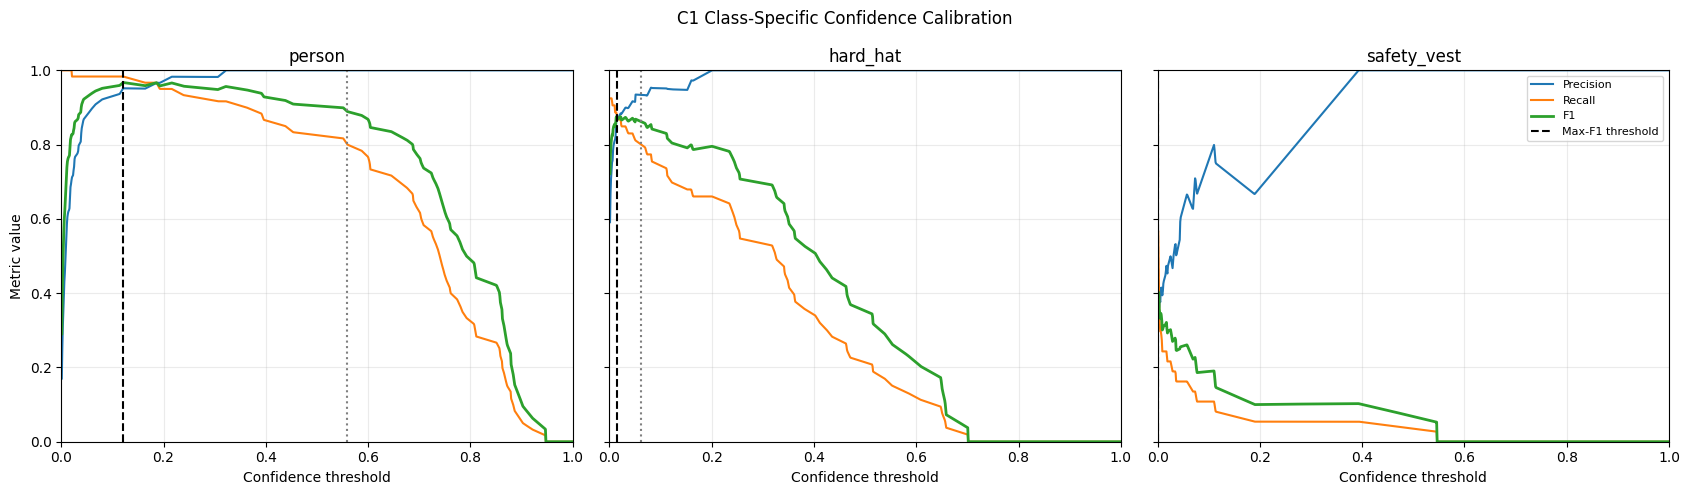

Results saved to: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/threshold_calibration/20260906T120247_682512Z


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
confidence_axis = np.asarray(
    metrics.box.px
)

precision_curves = np.asarray(
    metrics.box.p_curve
)

recall_curves = np.asarray(
    metrics.box.r_curve
)

f1_curves = np.asarray(
    metrics.box.f1_curve
)

class_indices = np.asarray(
    metrics.box.ap_class_index
).astype(int)

RECALL_TARGET = 0.80
DEFAULT_THRESHOLD = 0.25

records = []
recall_target_indices = {}

for curve_row, class_id in enumerate(
    class_indices
):
    class_name = CLASS_NAMES[class_id]

    precision_values = precision_curves[
        curve_row
    ]

    recall_values = recall_curves[
        curve_row
    ]

    f1_values = f1_curves[
        curve_row
    ]

    best_f1_index = int(
        np.nanargmax(f1_values)
    )

    default_index = int(
        np.argmin(
            np.abs(
                confidence_axis
                - DEFAULT_THRESHOLD
            )
        )
    )

    valid_recall_indices = np.where(
        recall_values >= RECALL_TARGET
    )[0]

    if len(valid_recall_indices) > 0:
        recall_index = int(
            valid_recall_indices[-1]
        )

        recall_target_indices[
            class_name
        ] = recall_index

        recall_candidate = {
            "recall_80_available": True,
            "recall_80_threshold": float(
                confidence_axis[recall_index]
            ),
            "precision_at_recall_80": float(
                precision_values[recall_index]
            ),
            "recall_at_recall_80": float(
                recall_values[recall_index]
            ),
            "f1_at_recall_80": float(
                f1_values[recall_index]
            ),
        }
    else:
        recall_target_indices[
            class_name
        ] = None

        recall_candidate = {
            "recall_80_available": False,
            "recall_80_threshold": None,
            "precision_at_recall_80": None,
            "recall_at_recall_80": None,
            "f1_at_recall_80": None,
        }

    record = {
        "class_id": int(class_id),
        "class_name": class_name,
        "prompt": C1_PROMPTS[class_id],
        "max_f1_threshold": float(
            confidence_axis[best_f1_index]
        ),
        "precision_at_max_f1": float(
            precision_values[best_f1_index]
        ),
        "recall_at_max_f1": float(
            recall_values[best_f1_index]
        ),
        "max_f1": float(
            f1_values[best_f1_index]
        ),
        "precision_at_0_25": float(
            precision_values[default_index]
        ),
        "recall_at_0_25": float(
            recall_values[default_index]
        ),
        "f1_at_0_25": float(
            f1_values[default_index]
        ),
        **recall_candidate,
    }

    records.append(record)

threshold_df = pd.DataFrame(records)

display_columns = [
    "class_name",
    "max_f1_threshold",
    "precision_at_max_f1",
    "recall_at_max_f1",
    "max_f1",
    "recall_80_threshold",
    "precision_at_recall_80",
    "f1_at_recall_80",
]

display(
    threshold_df[
        display_columns
    ].style.format({
        "max_f1_threshold": "{:.3f}",
        "precision_at_max_f1": "{:.2%}",
        "recall_at_max_f1": "{:.2%}",
        "max_f1": "{:.2%}",
        "recall_80_threshold": (
            lambda value:
            "Unavailable"
            if pd.isna(value)
            else f"{value:.3f}"
        ),
        "precision_at_recall_80": "{:.2%}",
        "f1_at_recall_80": "{:.2%}",
    })
)

# Plot confidence curves
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharey=True,
)

for curve_row, class_id in enumerate(
    class_indices
):
    class_name = CLASS_NAMES[class_id]
    ax = axes[curve_row]

    ax.plot(
        confidence_axis,
        precision_curves[curve_row],
        label="Precision",
    )

    ax.plot(
        confidence_axis,
        recall_curves[curve_row],
        label="Recall",
    )

    ax.plot(
        confidence_axis,
        f1_curves[curve_row],
        label="F1",
        linewidth=2,
    )

    max_f1_threshold = threshold_df.loc[
        threshold_df["class_name"]
        == class_name,
        "max_f1_threshold",
    ].iloc[0]

    ax.axvline(
        max_f1_threshold,
        color="black",
        linestyle="--",
        label="Max-F1 threshold",
    )

    recall_index = recall_target_indices[
        class_name
    ]

    if recall_index is not None:
        ax.axvline(
            confidence_axis[recall_index],
            color="gray",
            linestyle=":",
            label="Recall ≥ 0.80",
        )

    ax.set_title(class_name)
    ax.set_xlabel("Confidence threshold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Metric value")
axes[-1].legend(
    loc="best",
    fontsize=8,
)

fig.suptitle(
    "C1 Class-Specific Confidence Calibration"
)

plt.tight_layout()

curve_path = (
    RUN_ROOT
    / "class_threshold_curves.png"
)

plt.savefig(
    curve_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

csv_path = (
    RUN_ROOT
    / "threshold_candidates.csv"
)

json_path = (
    RUN_ROOT
    / "threshold_candidates.json"
)

threshold_df.to_csv(
    csv_path,
    index=False,
)

payload = {
    "dataset_role":
        "development_only_not_final_test",
    "model": "yolov8s-worldv2.pt",
    "prompts": C1_PROMPTS,
    "image_count": 12,
    "ground_truth_counts": {
        CLASS_NAMES[class_id]: count
        for class_id, count
        in sorted(counts.items())
    },
    "validation_map50": float(
        metrics.box.map50
    ),
    "validation_map50_95": float(
        metrics.box.map
    ),
    "recall_target": RECALL_TARGET,
    "default_threshold": DEFAULT_THRESHOLD,
    "candidates": records,
}

json_path.write_text(
    json.dumps(
        payload,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    ),
    encoding="utf-8",
)

archive_base = (
    Path("/content")
    / f"threshold_calibration_{RUN_ID}"
)

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=RUN_ROOT,
)

print("Results saved to:", RUN_ROOT)
files.download(archive_path)